# Neural Approximation of Dynamic Programming Solutions: Evidence from the Rust Bus Replacement Model

## Table of Contents 

1. Introduction

2. Constructing the Classical Rust Benchmark

3. The Computational Crisis of Classical Dynamic Programming

4. Evaluating Alternative Learning Targets for Neural Approximation

5. Deep Learning Approximation of the Dynamic Decision Problem

6. Discussion and Conclusions

# 1 Introduction

## 1.1 Dynamic Decision-Making and Structural Modeling

Many real-world decisions are dynamic rather than static. Current actions often affect future opportunities, constraints, and outcomes, making decisions inherently intertemporal. As a result, decision makers must evaluate not only immediate consequences but also the future implications of their choices.

Understanding such behavior requires a framework that links actions to future states. **Dynamic decision-making** therefore views behavior as the outcome of forward-looking optimization, where decisions are made with consideration of both current and future consequences.

This perspective naturally motivates **structural modeling**. Rather than describing observed behavior through statistical correlations alone, structural models seek to recover the underlying decision mechanism that generates observed choices. The objective is to explain observed behavior in terms of preferences, constraints, expectations, and optimization.

## 1.2 Dynamic Programming and Structural Estimation 

**Dynamic programming** provides a formal framework for analyzing forward-looking behavior. A dynamic decision problem can be represented through states, actions, transition dynamics, and value functions. The central idea is that the value of a decision depends not only on its immediate payoff but also on its effect on future opportunities.

The recursive structure of dynamic programming is commonly represented through the **Bellman equation**, which characterizes optimal behavior over time. Solving the Bellman equation yields the value function and the associated optimal policy.

In empirical applications, researchers typically observe actions rather than preferences or value functions. **Structural estimation** addresses this challenge by using observed behavior to recover the parameters governing the underlying decision process. Dynamic programming therefore provides the behavioral model, while structural estimation links the model to data.

## 1.3 Computational Challenges and the Motivation for Approximation

Although dynamic programming provides a powerful framework for sequential decision-making, solving dynamic models often requires repeated Bellman iterations and fixed-point computations. As the state space expands, models increasingly suffer from the **curse of dimensionality**, making exact solutions difficult to obtain.

The challenge is amplified in **structural estimation**, where the dynamic optimization problem must be solved repeatedly for different parameter values. As a result, estimation can become substantially more expensive than solving the model itself. 

These limitations have motivated increasing interest in **approximation methods**. Rather than solving dynamic models exactly, approximation-based approaches seek to represent key components of the decision problem more efficiently while preserving their essential economic structure.

## 1.4 Project Objectives and Structure 

This project investigates whether **neural-network-based approximation methods** can efficiently approximate key objects in **dynamic programming**, while preserving the **economic structure** of the original model. 

Chapter 2 constructs a classical benchmark model based on dynamic programming and structural estimation. Chapter 3 examines the computational limitations of exact solution methods and motivates approximation-based approaches. Chapter 4 evaluates alternative neural learning targets within the dynamic decision framework. Chapter 5 provides an in-depth investigation of the selected neural method. Finally, Chapter 6 compares the neural approach with the classical benchmark and discusses the broader implications for dynamic structural models.


# 2 Constructing the Classical Rust Benchmark

## 2.1 The Rust Bus Engine Replacement Problem

Rust (1987) studies the engine replacement decisions of Harold Zurcher, the maintenance superintendent of Madison Metropolitan Bus Company. The central question is when an aging bus engine should be replaced.

The decision problem can be summarized as follows:

- **State:** accumulated mileage since the last engine replacement.
- **Actions:** **Keep** the current engine or **Replace** it with a rebuilt engine.
- **Trade-off:** replacement involves a large immediate cost, while keeping an aging engine leads to increasing maintenance expenses and a higher probability of breakdown.

A key feature of the problem is that **current decisions affect future states**. If the engine is kept, mileage continues to accumulate and the engine deteriorates further. If the engine is replaced, the mileage state is reset and the replacement cycle starts again. The decision maker therefore faces a sequence of interrelated choices rather than an isolated one-period decision.

Because future operating costs depend on today's action, the problem is inherently dynamic. A static model would compare only current maintenance and replacement costs and would therefore fail to explain preventive replacement, where engines are replaced before complete failure in anticipation of future deterioration. To capture this intertemporal trade-off, Rust formulates the problem as a **dynamic optimization problem** and models the replacement decision as a **regenerative optimal stopping problem**.

This framework later became the canonical example of a **dynamic discrete choice (DDC) model**, providing the foundation for the structural analysis of forward-looking decision making under uncertainty.

## 2.2 The Rust Bus Engine Replacement Dataset 

### 2.2.1 Data Source

The dataset used in this project is the Rust (1987) bus engine replacement dataset distributed through the `rust-data` repository maintained by the OpenSourceEconomics community: https://github.com/OpenSourceEconomics/rust-data

The repository contains the original bus engine replacement data together with the associated preprocessing functions.

### 2.2.2 Data Preparation

The raw data are stored in the original format used for the Rust bus engine replacement model. The preprocessing functions provided in the repository transform the original records into a structured dataset suitable for analysis.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import matplotlib.pyplot as plt

# Add the local rust-data repository to the Python path
sys.path.append("../data/rust-data")

from data.data_processing import data_reading, data_processing

The original Rust dataset is organized into several bus groups, each corresponding to a different set of buses in the Madison Metro fleet. In this project, I restrict the analysis to **bus group 4** in order to keep the empirical environment fixed across all solution methods.

In the Rust model, the condition of an engine is summarized by its accumulated mileage since the last replacement. As mileage increases, the engine becomes more likely to require maintenance and experience breakdowns, making mileage a key determinant of replacement decisions. To obtain a finite state space for dynamic programming, mileage is discretized into **5,000-mile intervals**. Each state index represents a mileage bin: state 0 corresponds to 0–4,999 miles, state 1 corresponds to 5,000–9,999 miles, and so on.

In [140]:
# Convert the original raw files into intermediate group-level pickle files.
data_reading()  

# Specify the data-processing configuration.
# Following Rust (1987), accumulated mileage is discretized into 5,000-mile intervals. 
init_dict = { "groups": "group_4", "binsize": 5000 }

# Process the selected bus group and construct the cleaned panel dataset.
df_clean = data_processing(init_dict)
df_clean.head()

state  mileage usage  decision
Bus_ID period                               
5297   0          0   2353.0   NaN         0
       1          1   6299.0   1.0         0
       2          2  10479.0   1.0         0
       3          3  15201.0   1.0         0
       4          4  20326.0   1.0         0

The dataset contains four main variables: 
- `state`: the discretized mileage state of the bus 
- `mileage`: the observed odometer reading 
- `usage`: the mileage increment used to model state transitions
- `decision`: the observed engine replacement decision

For the `decision` variable:
- `0` = keep the current engine 
- `1` = replace the engine 

In [141]:
# Convert key variables to numeric format for analysis.
df_clean["state"] = pd.to_numeric(df_clean["state"])
df_clean["mileage"] = pd.to_numeric(df_clean["mileage"])
df_clean["usage"] = pd.to_numeric(df_clean["usage"])

# Generate descriptive statistics for all numeric variables
df_clean.describe()

,state,mileage,usage,decision
count,4329.000000,4329.000000,4292.000000,4329.000000
mean,25.395934,129454.487179,0.620923,0.007623
std,18.940754,94712.232318,0.510948,0.086986
min,0.000000,5.000000,0.000000,0.000000
25%,9.000000,47911.000000,0.000000,0.000000
50%,21.000000,109232.000000,1.000000,0.000000
75%,40.000000,203623.000000,1.000000,0.000000
max,77.000000,387282.000000,2.000000,1.000000


In [142]:
# Count the number of observations for each decision outcome.
df_clean["decision"].value_counts()

decision
0    4296
1      33
Name: count, dtype: int64

After preprocessing, the sample contains 4,329 monthly observations, 78 discretized mileage states, and 33 engine replacement events. 

## 2.3 Constructing the Dynamic Programming Model 

The objective of this section is to translate the processed dataset into the components required for dynamic programming. In the Rust framework, a dynamic decision model is characterized by a state space, an action space, transition dynamics, and a cost structure.

Since the objective of this project is to study neural approximation of dynamic programming solution objects rather than reproduce Rust’s original Nested Fixed Point (NFXP) estimation procedure, **the structural parameter estimates reported in Rust (1987) are taken** as given throughout the benchmark construction. These benchmark parameters are used to specify the transition dynamics and cost structure of the model.

### 2.3.1 Constructing Transition Dynamics

The transition dynamics describe how the mileage state evolves over time under different maintenance decisions. Following Rust (1987), the transition process is constructed using the estimated mileage increment parameters reported for Bus Group 4.

**Mileage Increment Process**

Rust assumes that mileage accumulation follows a discrete stochastic process. 

Let $$\Delta x_t = x_{t+1} - x_t$$ denote the mileage increment between two consecutive periods.

Under the discretized state representation, the mileage increment can take three possible values $$\Delta x_t \in \{0,1,2\}$$

These values represent increases of zero, one, or two mileage states within a single period.

**Transition Probabilities under Keep**

Following Rust (1987), the mileage increment process is characterized by the probabilities $$Pr(\Delta x_t = 0)=p_0$$ $$Pr(\Delta x_t = 1)=p_1$$ $$Pr(\Delta x_t = 2)=p_2$$

For Bus Group 4, the estimated transition parameters reported in Table V are $$p_0 = 0.392$$ $$p_1 = 0.595$$ $$p_2 = 0.013$$

These probabilities determine the likelihood of observing different mileage increments when the engine remains in service.

**State Transitions under Keep**

When the current engine is retained, the next-period mileage state evolves according to $$x_{t+1}=x_t+\Delta x_t$$

As a result, the bus gradually moves toward higher mileage states over time. The probabilities $p_0$, $p_1$, and $p_2$ determine the speed at which mileage accumulates and the engine deteriorates over time.

**State Transitions under Replacement**

When the engine is replaced, the mileage state is reset to the condition of a new engine. The next-period state is therefore given by $$x_{t+1}=0+\Delta x_t$$

Consequently, $$x_{t+1}\in\{0,1,2\}$$

Replacement returns the system to the lowest mileage region while allowing for normal mileage accumulation during the following period.

**Transition Matrix Construction**

The transition dynamics can be summarized by the conditional transition probabilities $$P(x' \mid x,a)$$

Using the mileage increment probabilities above, two transition matrices are constructed:

- a **keep transition matrix**, describing state evolution when the current engine is retained;
- a **replacement transition matrix**, describing state evolution after engine replacement.

Each row of the transition matrix corresponds to $$Pr(x_{t+1}=x' \mid x_t=x,\ a_t=a)$$ and therefore represents a complete probability distribution over next-period states.

![](../figures/rust1987_tableV_transition_parameters.png)

In [144]:
# Construct Rust (1987) transition matrices using Group 4 transition probabilities.

# State space from the processed data.
# Each state is a 5,000-mile mileage-bin index.
states = np.sort(df_clean["state"].unique())
n_states = len(states)

# Rust (1987), Table V, Group 4 transition probabilities.
p0 = 0.392
p1 = 0.595
p2 = 0.013

# Transition matrix under the keep decision.
P_keep = np.zeros((n_states, n_states))

for i in range(n_states):
    P_keep[i, i] += p0

    if i + 1 < n_states:
        P_keep[i, i + 1] += p1
    else:
        P_keep[i, -1] += p1

    if i + 2 < n_states:
        P_keep[i, i + 2] += p2
    else:
        P_keep[i, -1] += p2

# Transition matrix under the replacement decision.
P_replace = np.zeros((n_states, n_states))

P_replace[:, 0] = p0
P_replace[:, 1] = p1
P_replace[:, 2] = p2

print("Number of states:", n_states)
print("Keep transition matrix shape:", P_keep.shape)
print("Replacement transition matrix shape:", P_replace.shape)
print("First five row sums of P_keep:", np.round(P_keep.sum(axis=1)[:5], 4))
print("First five row sums of P_replace:", np.round(P_replace.sum(axis=1)[:5], 4))

Number of states: 78
Keep transition matrix shape: (78, 78)
Replacement transition matrix shape: (78, 78)
First five row sums of P_keep: [1. 1. 1. 1. 1.]
First five row sums of P_replace: [1. 1. 1. 1. 1.]


The constructed transition matrices contain 78 mileage states, resulting in transition matrices of dimension $$78\times78$$. The first five row sums of both matrices are equal to one $[1,1,1,1,1]$.

Therefore, $$\sum_{x'}P(x'|x,a)=1$$ for every state-action pair, confirming that the constructed matrices satisfy the requirements of a valid Markov transition process.

The resulting matrices provide the numerical representation of the state transition process and serve as the transition component of the Rust benchmark model. Together with the cost structure introduced in the next section, they form the basis for the Bellman representation and numerical solution of the model.

### 2.3.2 Specifying the Cost Structure

The transition dynamics describe how the mileage state evolves over time, but they do not determine which action is economically desirable. To evaluate alternative decisions, the Rust model requires a cost structure that assigns an economic consequence to each action.

Following Rust (1987), two types of costs are considered:

- maintenance costs associated with continued engine operation;
- replacement costs incurred when a new engine is installed.

**Maintenance Costs**

The maintenance cost increases with the mileage state and is specified as $$MC(x)=0.001\,\theta_1 x$$

The parameter $\theta_1$ measures the sensitivity of maintenance costs to engine mileage.

**Replacement Costs**

Engine replacement requires a fixed replacement cost denoted by $$RC$$

Unlike maintenance costs, the replacement cost does not depend on the current mileage state.

**State-Dependent Costs**

The maintenance cost is state-dependent because engine deterioration accumulates over time. As mileage increases, engines experience greater wear and tear, more frequent maintenance requirements, and a higher likelihood of mechanical failure.

Consequently, $$MC(x)$$ is an increasing function of the mileage state.

**Action-Specific Cost Functions**

The economic consequences of the two available actions can therefore be summarized by the action-specific cost function $$C(x,a)$$

For the keep decision, $$C(x,\text{keep})=0.001\,\theta_1 x$$

For the replacement decision, $$C(x,\text{replace})=RC$$

These expressions define the per-period costs associated with each action and constitute the cost component of the dynamic programming model.

**Economic Interpretation of the Cost Structure**

The cost structure creates a trade-off between continued engine operation and engine replacement. Keeping the current engine avoids the immediate replacement cost but leads to higher expected maintenance costs as mileage accumulates. Replacing the engine requires paying a fixed replacement cost but resets the engine condition to a low-mileage state.

This trade-off is incorporated into the dynamic programming model through the action-specific cost function.

### 2.3.3 Markov Decision Process Representation

The engine replacement problem can now be represented as a finite-state Markov Decision Process (MDP).

The model consists of four components:
- a state space;
- an action space;
- transition dynamics;
- a cost structure.

**Formal MDP Representation**

The Rust model can be summarized as $$MDP=(X,A,P,C)$$

where 
- $X$ denotes the finite state space,
- $A$ denotes the action space,
- $P$ denotes the transition function,
- $C$ denotes the cost function.

More formally, the transition process is described by $$P(x' \mid x,a)$$，which gives the probability of moving from state $x$ to state $x'$ after taking action $a$.

The cost structure is represented by $$C(x,a)$$，which assigns a cost to each state-action pair.

**Role of the MDP in Bellman Optimization**

The Rust model satisfies the Markov property, meaning that all information relevant for future decision-making is summarized by the current mileage state.

Consequently, the future evolution of the system depends only on $$(x_t,a_t)$$ and not on the complete history of previous states and actions.

This property allows the dynamic optimization problem to be represented recursively through the Bellman equation.

**Transition to the Bellman Representation**

Having specified the state space, action space, transition dynamics, and cost structure, the dynamic programming model is now fully defined.

The next section uses $(X,A,P,C)$ to construct the Bellman equation and the solution objects of the Rust model.

## 2.4 Bellman Representation of the Dynamic Programming Problem 

Once the dynamic programming model has been constructed, the next step is to characterize the optimal decision problem implied by the model. This is achieved through the Bellman equation, which recursively evaluates the long-run consequences of alternative actions and forms the basis for the solution objects of the Rust model.

### 2.4.1 Bellman Equation

The Bellman equation provides the recursive representation of the decision problem. It states that the value of being in a given state is equal to the minimum of the expected discounted costs associated with all feasible actions.

In the Rust model, the decision maker compares the long-run cost of keeping the current engine with the long-run cost of replacing it. Because current decisions affect future states, the evaluation of an action must account for both immediate costs and future consequences.

Formally, the Bellman equation can be written as: $$V(x)=\min_{a\in A}\left\{C(x,a)+\beta E\left[V(x')|x,a\right]\right\}$$

where:
- $x \in X$ is the current state;
- $a \in A$ is the current action; 
- $A$ is the action space;
- $C(x,a)$ is the current-period cost function;
- $\beta \in (0,1)$ is the discount factor;
- $x'$ is the next-period state;
- $V(x)$ is the value function;
- $E[\cdot]$ denotes the expectation over future states.

Solving this fixed-point equation yields the solution to the dynamic programming problem. The Bellman equation therefore serves as the foundation for the solution objects used to characterize optimal behavior. Because current decisions affect future states through the transition dynamics, the Bellman equation provides a recursive framework for evaluating the long-run consequences of alternative actions.

### 2.4.2 Expected Value Representation

**Definition of the Expected Value Function**

Although the Bellman equation provides the theoretical characterization of the dynamic programming problem, Rust (1987) reformulates the model using an expected value representation that is more convenient for numerical solution.

The expected value function is denoted by $$EV(x)=E\left[V(x',\varepsilon') \mid x\right]$$ where the expectation is taken over future states and future random utility shocks.

The expected value function summarizes the expected continuation value associated with a given mileage state.


**Type-I Extreme Value Assumption**

Rust (1987) assumes that the unobserved utility shocks are independently and identically distributed according to the Type-I Extreme Value distribution. Under this assumption, the Bellman equation admits a closed-form representation in which the value function can be expressed using the log-sum-exp operator.

This result eliminates the need to integrate explicitly over the distribution of future shocks and substantially simplifies numerical computation.


**Expected Value Fixed-Point Representation**

Using the expected value formulation, the dynamic programming problem can be represented as a fixed-point problem.

The expected value function satisfies $$EV = T(EV)$$ where $$T(\cdot)$$ denotes the expected value operator implied by the Bellman equation.

The solution to the Rust model is therefore obtained by finding the fixed point of the expected value mapping.

**Relationship to the Bellman Equation**

The expected value representation is mathematically equivalent to the Bellman equation. Rather than solving directly for the value function, Rust transforms the dynamic optimization problem into a fixed-point problem involving the expected value function.

Consequently, solving for the expected value function is sufficient to characterize the solution of the dynamic programming problem.

**Motivation for the Expected Value Representation**

The expected value representation provides a computationally efficient formulation of the Rust model. By converting the Bellman equation into an expected value fixed-point problem, the dimensionality of the numerical problem is reduced and fixed-point algorithms can be applied directly.

For this reason, the expected value representation serves as the foundation for the benchmark solution procedure developed in the following section.

### 2.4.3 Action-Value Functions

**Definition of the Action-Value Functions**

The action-value function measures the expected value associated with taking a particular action in a given state and then continuing according to the dynamic structure of the model.

Formally, the action-value function is denoted by $$Q(x,a)$$

where $$x \in X$$ denotes the current state and $$a \in A$$ denotes a feasible action.

The action-value function provides an action-specific evaluation of future outcomes and therefore allows alternative decisions to be compared directly within the same state.


**Keep and Replace Action Values**

In the Rust model, two actions are available:

- Keep the current engine;
- Replace the engine.

The corresponding action-value functions are $$Q(x,\text{keep})$$ and $$Q(x,\text{replace})$$

These functions summarize the expected value associated with each action at a given mileage state.

Because both action values are evaluated within the same state, they can be compared directly to assess the relative attractiveness of keeping or replacing the engine.

**Relationship to the Expected Value Function**

The action-value functions are constructed from the expected value function.

For the keep decision, $$Q(x,\text{keep})=-C(x,\text{keep})+\beta\sum_{x'}P_{\text{keep}}(x'|x)EV(x')$$

For the replacement decision, $$Q(x,\text{replace})=-C(x,\text{replace})+\beta\sum_{x'}P_{\text{replace}}(x'|x)EV(x')$$

The expected value function therefore provides the continuation values required to evaluate each feasible action. Once the expected value function has been obtained, the corresponding action-value functions can be constructed directly for every mileage state.

### 2.4.4 Replacement Probability Function

**Definition of the Replacement Probability Function**

The replacement probability function describes the probability that the decision maker chooses engine replacement at a given mileage state.

Rather than assigning a deterministic action to each state, the Rust model characterizes behavior through choice probabilities.

The replacement probability is denoted by $$P(\text{replace}\mid x)$$. It represents the likelihood of observing a replacement decision conditional on the current mileage state.

**Logit Choice Representation**

Under the Type-I Extreme Value assumption introduced above, the replacement probability takes the logit form $$P(\text{replace}\mid x)=\frac{\exp\big(Q(x,\text{replace})\big)}{\exp\big(Q(x,\text{keep})\big)+\exp\big(Q(x,\text{replace})\big)}$$

Similarly, the probability of keeping the current engine is $$P(\text{keep}\mid x)=\frac{\exp\big(Q(x,\text{keep})\big)}{\exp\big(Q(x,\text{keep})\big)+\exp\big(Q(x,\text{replace})\big)}$$

These probabilities sum to one and provide a complete description of replacement behavior.

**Relationship to the Action-Value Functions**

The replacement probability function is derived directly from the action-value functions. For each mileage state, the action-value functions summarize the relative attractiveness of keeping and replacing the engine. Larger values of $$Q(x,\text{replace})$$ relative to $$Q(x,\text{keep})$$ lead to higher replacement probabilities.

Consequently, the action-value functions determine the replacement probability through the logit choice rule.

**Behavioral Interpretation**

The replacement probability function provides the behavioral implication of the dynamic programming model. While the expected value function summarizes continuation values and the action-value functions evaluate alternative actions, the replacement probability function translates these quantities into observable decision behavior.

As a result, it provides a direct link between the underlying dynamic optimization problem and the replacement decisions generated by the model.

## 2.5 Benchmark Solution of the Rust Model 

This section solves the dynamic programming model constructed in the previous sections. Using the benchmark transition parameters and structural cost parameters reported in Rust (1987), the Bellman equation is solved numerically to obtain the benchmark value function, action-value functions, and optimal policy function.

### 2.5.1 Numerical Implementation and Solution Procedure

This section implements the Rust benchmark model and solves the associated expected value fixed-point problem using Rust's numerical solution approach. The numerical implementation requires a finite state space, transition matrices, benchmark structural parameters, and action-specific cost functions.

**State Space and Transition Matrix**

Following Rust (1987), the benchmark solution is computed using a state space consisting of 90 discretized mileage states.

The transition dynamics are parameterized using the Group 4 mileage transition probabilities reported in Rust (1987, Table V)
$$
p_0 = 0.392,\qquad
p_1 = 0.595,\qquad
p_2 = 0.013.
$$

These parameters are used to construct the transition matrices $$P_{\text{keep}}\qquad\text{and}\qquad P_{\text{replace}}$$

**Benchmark Parameters and Cost Construction**

The benchmark implementation adopts the Group 4 parameter estimates reported in Rust (1987, Table IX)
$$
\beta = 0.9999,\qquad
\theta_1 = 2.293,\qquad
RC = 10.075.
$$

The state variable is represented as a mileage-bin index rather than accumulated mileage itself. Because each state corresponds to a 5,000-mile interval, the accumulated mileage associated with a state is recovered as $$\text{Mileage}=5000\times\text{State}$$

Following Rust (1987), maintenance costs are specified as $$MC(x)=0.001\,\theta_1 x$$, where $$x$$ denotes accumulated mileage measured in miles. Substituting the recovered mileage into the cost function yields the numerical maintenance cost vector used in the benchmark implementation.

The replacement cost is represented by the fixed cost parameter $$RC$$ and therefore does not vary across mileage states.

The numerical implementation is summarized below.

![](../figures/rust1987_tableIX_structural_parameters.png)

In [152]:
# Rust (1987), Table IX, Group 4 structural parameters.
beta = 0.9999
theta1 = 2.2930
RC = 10.0750

# Rust uses a fixed-point dimension of 90 states.
states = np.arange(90)
n_states = len(states)

# Rust (1987), Table V, Group 4 transition probabilities.
p0 = 0.392
p1 = 0.595
p2 = 0.013

# Construct the keep transition matrix.
P_keep = np.zeros((n_states, n_states))

# Construct the replacement transition matrix.
P_replace = np.zeros((n_states, n_states))

for s in range(n_states):

    P_keep[s, min(s, n_states - 1)] += p0
    P_keep[s, min(s + 1, n_states - 1)] += p1
    P_keep[s, min(s + 2, n_states - 1)] += p2

    P_replace[s, 0] += p0
    P_replace[s, 1] += p1
    P_replace[s, 2] += p2

# Convert mileage-state indices into accumulated mileage measured in thousand miles.
mileage_thousands = 5000 * states *0.001

# Construct maintenance costs.
keep_cost = 0.001 * theta1 * mileage_thousands

# Construct replacement costs.
replace_cost = np.full(n_states, RC)

print("Number of states:", n_states)
print("P_keep shape:", P_keep.shape)
print("P_replace shape:", P_replace.shape)
print("Keep cost shape:", keep_cost.shape)
print("Replace cost shape:", replace_cost.shape)
print("P_keep row sums:", P_keep.sum(axis=1).min(), P_keep.sum(axis=1).max())
print("P_replace row sums:", P_replace.sum(axis=1).min(), P_replace.sum(axis=1).max())

Number of states: 90
P_keep shape: (90, 90)
P_replace shape: (90, 90)
Keep cost shape: (90,)
Replace cost shape: (90,)
P_keep row sums: 1.0 1.0
P_replace row sums: 1.0 1.0


The output confirms that the benchmark implementation has been successfully initialized. The model contains 90 mileage states, resulting in transition matrices of dimension $90\times90$. The row sums of both transition matrices are equal to one, confirming that the transition probabilities form valid probability distributions. The maintenance cost vector and replacement cost vector are successfully constructed and have dimensions consistent with the state space.

Together, the transition matrices, benchmark parameters, and cost vectors provide the numerical inputs required for solving the expected value fixed-point problem.

**Expected Value Representation** 

Following Rust’s fixed-point solution approach, the Bellman equation is solved using the expected value representation rather than direct value function iteration. The numerical object of interest is the expected value function $$EV(x)$$

For each state, the choice-specific value of keeping the current engine is $$v_{\text{keep}}(x)=-C(x,\text{keep})+\beta\sum_{x'}P_{\text{keep}}(x'|x)EV(x')$$

Similarly, the value of replacing the engine is $$v_{\text{replace}}(x)=-C(x,\text{replace})+\beta\sum_{x'}
P_{\text{replace}}(x'|x)EV(x')$$

Following Rust (1987), the action-specific shocks are assumed to follow a Type-I Extreme Value distribution. This assumption yields a closed-form expression for the ex-ante value function $$V(x)=\log\left[\exp\big(v_{\text{keep}}(x)\big)+\exp\big(v_{\text{replace}}(x)\big)\right]$$ 

The expected value fixed-point mapping is therefore $$T(EV)(x)=\sum_{x'}P_{\text{keep}}(x'|x)V(x')$$

The expected value representation allows the dynamic programming problem to be written as a fixed-point problem in the expected value function. The benchmark solution is obtained by computing the fixed point satisfying $$EV(x)=T(EV)(x)$$.

**Newton-Kantorovich Fixed-Point Iteration**

In the numerical implementation, the residual is defined as $$r(EV)=EV-T(EV)$$

The fixed-point equation is solved using a Newton-Kantorovich algorithm. The update step is $$EV_{k+1}=EV_k-\left[I-DT(EV_k)\right]^{-1}\left[EV_k-T(EV_k)\right]$$

The Newton step exploits the derivative of the fixed-point mapping, $$DT(EV_k)$$, thereby achieving rapid convergence. This is particularly important in the Rust benchmark model because the discount factor is specified as $$\beta = 0.9999$$, which can make simple successive approximation computationally inefficient.

In [153]:
# Solve the Rust expected value fixed point using Newton-Kantorovich acceleration.
# Initialize the expected value function.
EV = np.zeros(n_states)

tolerance = 1e-8
max_iter = 1000
errors = []

for iteration in range(max_iter):
    EV_old = EV.copy()

    # Compute choice-specific value functions.
    v_keep = -keep_cost + beta * (P_keep @ EV_old)
    v_replace = -replace_cost + beta * (P_replace @ EV_old)

    # Compute the ex-ante value function using the log-sum-exp formula.
    max_v = np.maximum(v_keep, v_replace)
    V = max_v + np.log(np.exp(v_keep - max_v) + np.exp(v_replace - max_v))

    # Compute conditional choice probabilities implied by the logit structure.
    prob_keep = np.exp(v_keep - max_v) / (
        np.exp(v_keep - max_v) + np.exp(v_replace - max_v)
    )
    prob_replace = 1.0 - prob_keep

    # Apply the expected value fixed-point mapping.
    # Rust's EV representation defines EV as the expected continuation value conditional on the keep action.
    T_EV = P_keep @ V

    # Compute the fixed-point residual.
    residual = EV_old - T_EV

    # Compute the maximum absolute residual as the convergence error.
    error = np.max(np.abs(residual))
    errors.append(error)

    if error < tolerance:
        EV = EV_old
        break

    # Construct the derivative of the fixed-point mapping.
    D_keep = np.diag(prob_keep)
    D_replace = np.diag(prob_replace)

    # Derivative of the fixed-point mapping.
    # The Jacobian depends on the logit choice probabilities implied by the Type-I Extreme Value assumption.
    dT = beta * P_keep @ (D_keep @ P_keep + D_replace @ P_replace)

    # Apply the Newton-Kantorovich update.
    I = np.eye(n_states)
    step = np.linalg.solve(I - dT, residual)

    EV = EV_old - step

print("Iterations:", iteration + 1)
print("Final error:", error) 

Iterations: 8
Final error: 1.8189894035458565e-12


**Convergence Criterion**

The fixed-point algorithm is terminated when the maximum absolute residual of the expected value fixed-point equation falls below the specified tolerance level $$\max_x\left|EV(x)-T(EV)(x)\right|<10^{-8}$$

In the implementation, the stopping rule is:

```python
if error < tolerance:
    break
```

**Convergence Results**

The Newton-Kantorovich algorithm converges after 8 iterations and produces a final residual of $1.82\times10^{-12}$. This value is substantially smaller than the prescribed tolerance level $10^{-8}$, indicating that the expected value fixed point has been computed with a high degree of numerical accuracy.

The convergence path is illustrated below.

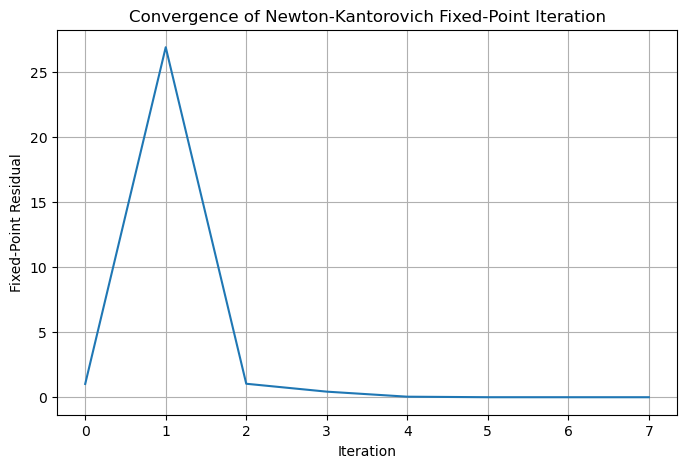

In [154]:
# Plot convergence path.
plt.figure(figsize=(8, 5))

plt.plot(errors)

plt.xlabel("Iteration")
plt.ylabel("Fixed-Point Residual")
plt.title("Convergence of Newton-Kantorovich Fixed-Point Iteration")

plt.grid(True)
plt.show() 

The convergence path exhibits a non-monotonic pattern during the initial iterations. The fixed-point residual increases sharply after the first update before declining rapidly thereafter.

This behavior is characteristic of Newton-type methods. Unlike simple fixed-point iteration, the Newton-Kantorovich algorithm does not necessarily reduce the residual at every step. Early iterations may temporarily move away from the solution while constructing a more accurate local approximation to the fixed-point mapping.

After the initial increase, the residual decreases by several orders of magnitude within only a few iterations and quickly approaches zero. The near-horizontal segment at the end of the convergence path indicates that further numerical improvements are negligible and that the fixed point has effectively been reached.

Overall, the figure demonstrates the rapid convergence of the Newton-Kantorovich algorithm and confirms the numerical stability of the benchmark solution procedure.

### 2.5.2 Benchmark Solution Objects

Solving the Rust expected value fixed-point problem produces three benchmark solution objects: the expected value function, the action-value functions, and the replacement probability function. 

The expected value function represents the fixed-point solution of the dynamic programming problem. The action-value functions evaluate the expected value associated with each feasible action, while the replacement probability function translates these action values into observable replacement behavior.

The following subsections present each benchmark solution object and its numerical properties.

**Expected Value Function**

The expected value function summarizes the expected continuation value associated with each mileage state.

Following the solution of the fixed-point problem, the benchmark expected value function is obtained directly from the converged fixed-point vector $EV(x)$.

The numerical implementation is shown below.

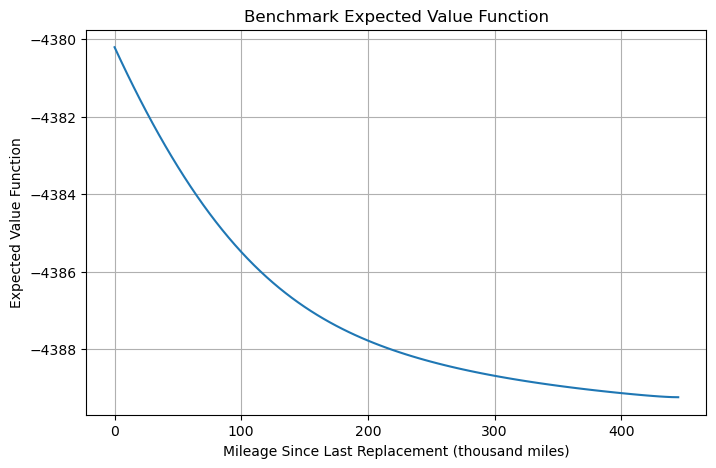

In [155]:
# Plot the benchmark expected value function using the converged fixed-point solution.
plt.figure(figsize=(8, 5))

plt.plot(states * 5000 * 0.001, EV)

plt.xlabel("Mileage Since Last Replacement (thousand miles)")
plt.ylabel("Expected Value Function")
plt.title("Benchmark Expected Value Function")

plt.grid(True)
plt.show()

The benchmark expected value function is plotted above.

The expected value function declines monotonically as mileage increases, indicating that the expected continuation value becomes progressively lower at higher mileage states.

The decline is relatively steep at low and intermediate mileage levels, while the slope gradually flattens at higher mileage levels. This pattern suggests that increases in mileage have a larger effect on expected continuation values when the engine is relatively new, whereas the marginal effect becomes smaller as mileage accumulates. The smooth and monotonic shape of the function reflects the cumulative impact of engine deterioration. Higher mileage states are associated with greater expected operating costs and therefore lower continuation values.

Overall, the figure shows that the benchmark expected value function varies systematically with mileage and provides a smooth mapping from engine condition to expected continuation value. This expected value function serves as the foundation for constructing the benchmark action-value functions and replacement probabilities examined below.

**Action-Value Functions**

The action-value functions measure the expected value associated with each feasible action at a given mileage state. Since the Rust model is formulated in utility terms, with utility defined as the negative of operating costs, higher action values correspond to more attractive decisions.

For the keep decision, $$Q(x,\text{keep})=-C(x,\text{keep})+\beta\sum_{x'}P_{\text{keep}}(x'|x)EV(x')$$

For the replacement decision, $$Q(x,\text{replace})=-C(x,\text{replace})+\beta\sum_{x'}P_{\text{replace}}(x'|x)EV(x')$$

The benchmark action-value functions are constructed directly from the converged expected value function and provide an action-specific evaluation of the keep and replacement decisions.

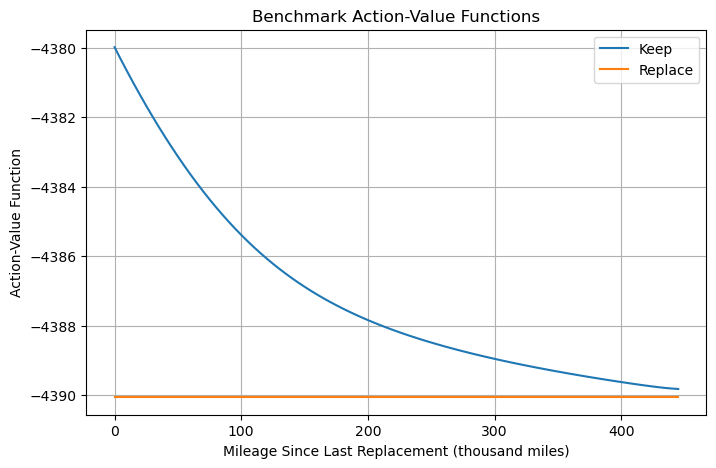

In [157]:
# Compute benchmark action-value functions using the converged expected value solution.
Q_keep = -keep_cost + beta * (P_keep @ EV)
Q_replace = -replace_cost + beta * (P_replace @ EV)

plt.figure(figsize=(8, 5))

plt.plot(states * 5000 * 0.001, Q_keep, label="Keep")
plt.plot(states * 5000 * 0.001, Q_replace, label="Replace")

plt.xlabel("Mileage Since Last Replacement (thousand miles)")
plt.ylabel("Action-Value Function")
plt.title("Benchmark Action-Value Functions")

plt.legend()
plt.grid(True)
plt.show()

The benchmark action-value functions are plotted above.

The action value associated with keeping the current engine declines steadily as mileage increases, whereas the replacement action value remains nearly constant across mileage states. As mileage accumulates, the gap between the two action-value functions becomes progressively smaller. The smallest difference occurs at the highest mileage state, where the two functions become very close but do not intersect.

The different shapes of the two functions reflect the underlying structure of the Rust model. The keep action becomes less attractive as mileage increases because higher mileage is associated with greater expected operating costs. In contrast, the replacement action value remains relatively stable because the replacement cost is fixed and replacement resets the engine condition to a low-mileage state. Consequently, replacement becomes increasingly attractive as mileage accumulates, even though the keep action continues to yield a slightly higher action value throughout the benchmark state space.

Overall, the figure shows that the relative attractiveness of the keep and replacement decisions varies systematically with mileage. The narrowing gap between the two action-value functions provides the basis for constructing the benchmark replacement probability function examined in the next section.

**Replacement Probability Function**

The replacement probability function translates the benchmark action-value functions into the probability of choosing engine replacement at each mileage state.

Under the Type-I Extreme Value assumption, the replacement probability is given by the logit choice rule $$P(\text{replace}\mid x)=\frac{\exp\left(Q(x,\text{replace})\right)}{\exp\left(Q(x,\text{keep})\right)+\exp\left(Q(x,\text{replace})\right)}$$

Similarly, the probability of keeping the current engine is $$P(\text{keep}\mid x)=\frac{\exp\left(Q(x,\text{keep})\right)}{\exp\left(Q(x,\text{keep})\right)+\exp\left(Q(x,\text{replace})\right)}$$

The replacement probability function therefore provides the behavioral implication of the benchmark action-value functions.

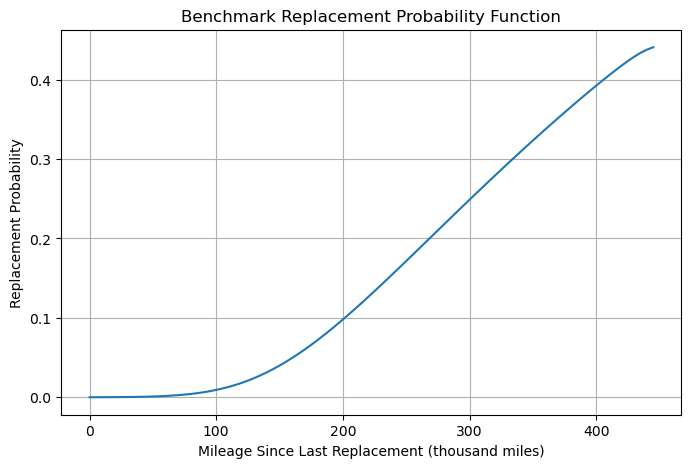

In [160]:
# Compute benchmark replacement probabilities from the action-value functions using the Rust logit choice rule.
max_Q = np.maximum(Q_keep, Q_replace)

prob_replace = np.exp(Q_replace - max_Q) / (
    np.exp(Q_keep - max_Q) + np.exp(Q_replace - max_Q)
)

plt.figure(figsize=(8, 5))

plt.plot(states * 5000 * 0.001, prob_replace)

plt.xlabel("Mileage Since Last Replacement (thousand miles)")
plt.ylabel("Replacement Probability")
plt.title("Benchmark Replacement Probability Function")

plt.grid(True)
plt.show()

The benchmark replacement probability function is plotted above.

The replacement probability remains close to zero at low mileage levels and increases gradually as mileage accumulates. The curve becomes substantially steeper over the middle range of the state space, indicating a rapid increase in the likelihood of replacement. At very high mileage levels, the slope begins to flatten, suggesting that further mileage increases have a smaller marginal effect on replacement probability.

This nonlinear pattern arises from the logit transformation of the benchmark action-value functions. At low mileage levels, the keep action yields a substantially higher action value than replacement, resulting in replacement probabilities close to zero. As mileage increases, the gap between the keep and replacement action values narrows, causing replacement probabilities to rise more rapidly. At very high mileage levels, the two action values become relatively close, and the probability function begins to approach an upper range, producing the observed flattening of the curve.

Overall, the figure shows that replacement behavior varies systematically with engine mileage. The benchmark replacement probability function provides a smooth behavioral mapping from mileage states to replacement decisions and represents the final behavioral implication of the benchmark dynamic programming solution.

### 2.5.3 Economic Interpretation of the Benchmark Solution

The benchmark solution reveals the fundamental economic mechanism underlying the Rust engine replacement problem. The central trade-off is not between current maintenance costs and current replacement costs, but between current costs and the future consequences of today's decision.

The **expected value function** shows that engine deterioration reduces the long-run value of remaining in a given state. As mileage accumulates, future operating costs become increasingly burdensome, lowering the expected continuation value associated with the current engine. The economic cost of deterioration therefore extends beyond current-period maintenance expenses and affects the entire stream of future operating outcomes.

The **action-value functions** provide a more direct view of the decision problem. Keeping the current engine allows the decision maker to avoid the immediate replacement cost, but exposes the bus to continued deterioration and higher future operating costs. Replacing the engine requires a substantial one-time expenditure, but restores the engine to a low-mileage condition and improves future operating prospects. The replacement decision therefore reflects an intertemporal comparison between preserving current resources and improving future conditions.

The **replacement probability function** illustrates how this trade-off translates into behavior. Rather than generating an abrupt switch between actions, the model produces a gradual increase in replacement likelihood as mileage accumulates. Replacement becomes increasingly attractive as deterioration worsens, but uncertainty in the decision environment implies that replacement behavior emerges as a probability rather than a deterministic rule.

Taken together, the expected value function, action-value functions, and replacement probability function provide a coherent description of the Rust dynamic decision problem. The expected value function summarizes future consequences, the action-value functions compare alternative decisions, and the replacement probability function translates these comparisons into observable behavior. Together they reveal how cumulative deterioration and costly renewal generate optimal replacement decisions over time and provide a quantitative representation of the dynamic trade-off at the core of the Rust model.

# 3 The Computational Crisis of Classical Dynamic Programming

This chapter discusses the main computational bottlenecks of classical dynamic programming and reviews the major methodological responses that emerged in response to these challenges. The discussion is general in scope, but the Rust bus replacement model serves as the guiding example throughout the chapter.

In general dynamic programming, the value function is the canonical solution object. In the Rust framework, however, the numerical solution is conveniently represented through the expected value fixed point. This chapter therefore uses the classical value function notation when discussing dynamic programming in general, and the expected value representation when referring specifically to the Rust benchmark and the approximation targets used in this project.

## 3.1 Computational Bottlenecks in Classical Dynamic Programming

The computational burden of the Rust framework originates from two related but distinct sources. The first arises from solving the Bellman equation itself, while the second emerges when dynamic programming is repeatedly embedded within structural estimation. Together, these two sources form the foundation of what is often referred to as the computational crisis of classical dynamic programming.

### 3.1.1 Core Bellman Computation Bottlenecks

The Bellman equation provides the fundamental recursive representation of the Rust model. By characterizing optimal decisions through a fixed-point problem, it transforms a dynamic optimization problem into a computational problem.

The dynamic programming solution is characterized by a fixed-point equation. In the classical Bellman representation, this fixed point is written as $$V=T(V)$$

In practice, closed-form solutions are rarely available. The value function must therefore be computed numerically through repeated applications of the Bellman operator $$V^{(k+1)}=T\!\left(V^{(k)}\right)$$ 

until convergence to $$V^{*}$$ is achieved.

While this recursive formulation provides a theoretically attractive characterization of optimal behavior, solving the Bellman equation requires repeated evaluations over the state space. As the complexity of the dynamic decision problem increases, several computational bottlenecks emerge that substantially increase the cost of exact dynamic programming.

#### Bottleneck 1 - Repeated Bellman Iteration

The Bellman equation transforms a dynamic optimization problem into a fixed-point problem. Although this formulation is conceptually simple, the fixed point is generally not available analytically and must instead be computed through repeated iteration.

The benchmark solution is obtained by repeatedly applying the Bellman operator $$V(x)=\max_{a\in\{0,1\}}\left\{u(x,a)+\beta\sum_{x'}P(x'|x,a)V(x')\right\}$$

The corresponding value iteration procedure is $$V^{(k+1)}=T(V^{(k)})$$

The computational process therefore takes the form $$V^{(0)}\rightarrow V^{(1)}\rightarrow V^{(2)}\rightarrow \cdots\rightarrow V^{*}$$

Each iteration requires evaluating the Bellman equation for every state in the state space. Consequently, the computational burden grows with both the size of the state space and the number of iterations required for convergence. Even when convergence is guaranteed, repeated fixed-point iteration can become computationally expensive in large-scale dynamic decision problems.

#### Bottleneck 2 - Curse of Dimensionality

A more fundamental challenge arises from the dimensionality of the state space itself.

Suppose the state vector contains multiple state variables $$x=(x_1,x_2,\ldots,x_d)$$

If each dimension is discretized into $$n$$ grid points, the total number of states becomes $$|S|=n^d$$

For example, $$100^1 = 100$$ $$100^2 = 10,000$$ $$100^3 = 1,000,000$$

The number of states therefore grows exponentially with the number of state variables. This phenomenon is known as the curse of dimensionality.

The importance of this bottleneck extends beyond memory requirements. Because Bellman iteration must be evaluated at every state, exponential growth in the state space directly translates into exponential growth in computational cost. As a result, exact dynamic programming quickly becomes infeasible as additional state variables are introduced. 

#### Bottleneck 3 - Memory and State Explosion

Classical dynamic programming requires explicit storage of the value function over the entire state space.

The value function can be represented as $$V=\{V(x_1),V(x_2),\ldots,V(x_{|S|})\}$$

The memory requirement therefore scales approximately as $$O(|S|)$$

In addition, dynamic programming requires storage of transition probabilities $$P=\big[P(x'|x,a)\big]$$

The number of transition elements can grow on the order of $$O(|S|^2)$$

Consequently, increases in state-space dimensionality generate not only computational challenges but also substantial storage requirements. In many practical applications, memory constraints become a limiting factor before Bellman iteration itself becomes the dominant computational cost. 

#### Bottleneck 4 - Numerical Stability and Convergence

Theoretical convergence does not necessarily imply computational efficiency.

Bellman iteration converges because the Bellman operator is a contraction mapping $$\|TV-TW\|\le\beta\|V-W\|$$

When the discount factor satisfies $$\beta \rightarrow 1$$ the fixed point exists and convergence is guaranteed.

However, as $$\beta\rightarrow1$$ the contraction becomes weaker. Successive iterations therefore generate smaller improvements, causing convergence to slow substantially.

As a result, dynamic programming problems with highly persistent future values often require many additional iterations before convergence is achieved. In large-scale environments, the resulting computational burden can become substantial even when the theoretical properties of the Bellman operator remain unchanged.

### 3.1.2 The Burden of Nested Fixed Point Estimation

The computational burden increases further when structural parameters must be estimated. In Rust's Nested Fixed Point (NFXP) framework, dynamic programming is embedded within likelihood optimization, creating an additional layer of computational complexity beyond the Bellman computation itself.

Structural estimation requires recovering the economic parameters that govern dynamic decision-making, such as replacement costs, maintenance costs, and discount factors. Unlike the solution of the Bellman equation, which assumes that the parameters are known, structural estimation treats these parameters as unknown and infers them from observed choices.

In the Rust framework, estimation proceeds by comparing observed decisions with the decisions implied by the dynamic programming model. 

For a given parameter vector $\theta$, the dynamic programming problem must first be solved. In classical dynamic programming this solution is often represented by the value function $V_\theta(x)$. In the Rust framework, however, the numerical solution is conveniently represented by the expected value function $EV_\theta(x)$. These solution objects then determine the choice probabilities $P(a|x;\theta)$, which can be compared with observed replacement decisions in the data.

The likelihood function measures how well the model explains the observed choices $$L(\theta)=\prod_{i=1}^{N}\prod_{t=1}^{T}P(a_{it}\mid x_{it};\theta)$$

Structural estimation therefore searches for the parameter vector that makes the observed decisions most likely under the model.

The estimation problem can be summarized as $$\hat{\theta}=\arg\max_{\theta}L(\theta)$$

The importance of this computational burden extends beyond the Rust model itself. The Nested Fixed Point algorithm became one of the foundational estimation methods in the dynamic discrete choice literature because it combines structural estimation with the exact solution of the underlying dynamic programming problem. However, this theoretical rigor comes at a substantial computational cost. Every parameter update requires a new solution of the Bellman equation, causing estimation time to increase rapidly as model complexity grows.

 The NFXP framework provides a conceptually appealing estimation strategy because likelihood evaluation is based on the exact solution of the dynamic programming problem. However, this theoretical appeal comes at a substantial computational cost.

For every candidate parameter vector $$\theta$$, the dynamic programming fixed point must first be solved before the likelihood can be evaluated. In the Rust expected value representation, this fixed point can be written as $$EV_{\theta}=T_{\theta}(EV_{\theta})$$. The resulting computational structure is therefore $$\theta\;\longrightarrow\;EV_{\theta}\;\longrightarrow\;P(a|x;\theta)\;\longrightarrow\;L(\theta)$$.

Dynamic programming is therefore nested within likelihood optimization. Every parameter update requires a new solution of the Bellman equation, causing computational costs to increase dramatically as model complexity grows.

![](../figures/nfxp_workflow.png)

#### Bottleneck 5 - Repeated Dynamic Programming within Likelihood Optimization

The key difficulty of NFXP is that likelihood evaluation cannot be separated from the dynamic programming problem itself.

The structural likelihood can be written as $$L(\theta)=\prod_{i=1}^{N}\prod_{t=1}^{T}P(a_{it}\mid x_{it};\theta)$$

However, the choice probabilities are not directly generated by the parameter vector. Instead, they are implied by the optimal solution of the dynamic programming problem.

For a given parameter vector $\theta$, the dynamic programming fixed point must first be solved. In the expected value representation, this can be written as $$EV_{\theta}=T_{\theta}(EV_{\theta})$$. The resulting solution determines the model-implied choice probabilities $P(a|x;\theta)$, which are then used to evaluate the likelihood function. The estimation procedure therefore follows the sequence $$\theta\rightarrow EV_{\theta}\rightarrow P(a|x;\theta)\rightarrow L(\theta)$$. Whenever the parameter vector changes,
$$
\theta^{(1)}\rightarrow EV^{(1)},\qquad
\theta^{(2)}\rightarrow EV^{(2)},\qquad
\theta^{(3)}\rightarrow EV^{(3)},
$$
the dynamic programming problem must be solved again.

The crucial point is that the computational burden arises not because solving a single Bellman equation is necessarily difficult, but because the Bellman equation must be solved repeatedly throughout the optimization procedure. Even relatively small parameter updates require a new value-function solution and a new likelihood evaluation.

As a result, the computational challenge shifts from solving one dynamic programming problem to repeatedly solving many closely related dynamic programming problems during estimation. This nested structure is the defining characteristic of the NFXP algorithm and one of the primary reasons why structural dynamic models became computationally demanding.

#### Bottleneck 6 - Computational Scaling of Structural Estimation

The computational burden of NFXP grows multiplicatively because dynamic programming and likelihood optimization are nested within one another.

Let $$N_V$$ denote the number of Bellman iterations required to solve the value function. Let $$N_{\theta}$$ denote the number of likelihood evaluations required during estimation. The overall computational burden can be approximated by $$O(N_{\theta}N_V|S|)$$

Unlike the Bellman problem alone, structural estimation must simultaneously account for all three dimensions of complexity.

An increase in the size of the state space $$|S|\uparrow$$ raises the computational cost of each Bellman iteration. An increase in model complexity often increases the number of iterations required for convergence $$N_V\uparrow$$ Similarly, a larger parameter space generally requires more likelihood evaluations during optimization $$N_{\theta}\uparrow$$

The important implication is that these sources of complexity do not operate independently. Because they interact through the nested structure of the estimation problem, computational costs can increase much faster than suggested by any individual component.

For relatively simple models, the resulting burden may remain manageable. However, as researchers introduce additional state variables, richer transition dynamics, or more flexible behavioral specifications, estimation costs can grow rapidly. In many applications, solving the dynamic programming problem is no longer the primary challenge; the challenge becomes solving it repeatedly inside a large-scale optimization routine.

This scaling problem became one of the central motivations for subsequent methodological developments. Some approaches attempted to reduce the need for repeated Bellman solutions during estimation, while others sought more efficient ways to represent and compute Bellman-based solution objects themselves.

## 3.2 Historical Responses to the Computational Crisis of Dynamic Programming 

The computational limitations of classical dynamic programming motivated a large methodological literature aimed at reducing the cost of solving and estimating dynamic decision models. Over time, two broad routes emerged. One focused on reducing the computational burden of structural estimation, while the other sought more efficient ways to approximate Bellman-based solutions within the dynamic programming framework.

![](../figures/historical_tree.png)

### 3.2.1 Econometric Route 

The econometric route seeks to reduce the computational burden of structural estimation by avoiding repeated solutions of the Bellman equation.

Under the original Nested Fixed Point framework, each parameter update requires solving the fixed point $$V_{\theta}=T_{\theta}(V_{\theta})$$ 

before evaluating the likelihood function $$L(\theta)=\prod_{i=1}^{N}\prod_{t=1}^{T}P(a_{it}\mid x_{it};\theta)$$ or equivalently the log-likelihood $$\ell(\theta)=\sum_{i=1}^{N}\sum_{t=1}^{T}\log P(a_{it}\mid x_{it};\theta)$$ 

The computational objective therefore becomes $$\min\Big(\text{Number of Bellman Solves}\Big)$$ 

Rather than repeatedly solving the dynamic programming problem, econometric approaches attempt to recover structural information through alternative representations of the decision process.

#### Conditional Choice Probability Methods 

Conditional Choice Probability (CCP) methods were developed to reduce the computational burden associated with repeatedly solving the Bellman equation during structural estimation. 

The central insight is that observed choice probabilities contain information about the underlying value function. Rather than solving the dynamic programming problem for every parameter vector, CCP methods exploit the relationship between observed decisions and continuation values. 

Let$$P(a|x)=\Pr(a_t=a\mid x_t=x)$$ 

Under suitable assumptions, these probabilities can be linked to differences in choice-specific value functions $$Q(x,a)=u(x,a)+\beta E[V(x')|x,a]$$ 

Hotz and Miller (1993) showed that a one-to-one mapping exists between conditional choice probabilities and value-function differences $$P(a|x)\Longleftrightarrow Q(x,a)-Q(x,a')$$ 

As a result, portions of the dynamic programming problem can be recovered through inversion of observed choice probabilities rather than through repeated Bellman iteration. 

The main contribution of CCP methods is computational efficiency. By replacing repeated value-function solutions with probability inversion, structural estimation becomes substantially faster. 

However, the approach does not eliminate the dynamic programming structure itself. Accurate estimation still requires reliable estimates of conditional choice probabilities, and the method becomes increasingly difficult in environments with large action spaces, sparse observations, or high-dimensional state variables. 

#### Mathematical Programming Approaches 

A second branch of the econometric route reformulates the estimation problem itself rather than modifying the underlying dynamic model. The most influential example is Mathematical Programming with Equilibrium Constraints (MPEC). 

Under Rust's Nested Fixed Point algorithm, parameter estimation requires solving $$V_{\theta}=T_{\theta}(V_{\theta})$$ for every candidate parameter vector before evaluating the likelihood function $$L(\theta)$$ MPEC removes this nested structure by treating the value function as an optimization variable. 

The estimation problem becomes $$\max_{\theta,V}L(\theta,V)$$ 

subject to $$V=T_{\theta}(V)$$ 

The Bellman equation therefore appears as an equilibrium constraint rather than as an inner optimization problem. This reformulation can significantly reduce the computational cost associated with repeated Bellman solutions and allows modern nonlinear optimization algorithms to be applied directly. 

Nevertheless, the Bellman equation remains part of the estimation problem. As the state space grows, the number of equilibrium constraints increases rapidly, which can generate large-scale constrained optimization problems that remain computationally demanding. 

#### Simulation-Based Methods 

Simulation-based methods address the computational burden of evaluating expectations that arise in dynamic programming and structural estimation. 

Many dynamic decision models require the computation of expected continuation values of the form $$E[V(x')]=\int V(x')p(x'|x,a)dx'$$ 

When the state space is large or the transition process is complex, evaluating this expectation exactly can become computationally expensive. 

Simulation methods replace analytical integration with simulated draws $$E[V(x')]\approx\frac{1}{N}\sum_{i=1}^{N}V(x'_i),\qquad x'_i\sim p(x'|x,a)$$ 

The key advantage is flexibility. Simulation methods can accommodate complicated transition dynamics, latent variables, and high-dimensional stochastic processes that are difficult to integrate analytically.

However, simulation introduces sampling noise. Accuracy depends on the number of simulated observations, and computational costs may increase substantially when high precision is required. Consequently, simulation often replaces one computational problem with another: exact integration is avoided, but a large number of simulations may be needed to obtain stable estimates.

### 3.2.2 Computational Route 

The computational route emerged from a different perspective on the computational crisis of dynamic programming. Rather than reducing the burden of structural estimation, this literature focuses on reducing the cost of representing and computing Bellman-based solution objects themselves. 

Instead of avoiding the fixed-point problem, the objective of the computational route is to approximate the main solution objects generated by dynamic programming more efficiently.

In classical dynamic programming, these objects are often represented by value functions, action-value functions, or policy functions. In the Rust framework, however, the expected value representation provides a convenient alternative fixed-point formulation.

Accordingly, the present study focuses on three Rust solution objects:
$$
EV_{\theta}(x),\quad
Q_{\theta}(x,a),\quad
P_{\theta}(a|x).
$$
Here, $EV_{\theta}(x)$ denotes the expected value function, $Q_{\theta}(x,a)$ denotes the action-value function, and $P_{\theta}(a|x)$ denotes the model-implied choice probability.

These objects are linked through the Rust expected value structure: $$Q_{\theta}(x,a)=u_{\theta}(x,a)+\beta\sum_{x'}F_{\theta}(x'|x,a)EV_{\theta}(x')$$. Under the Type-I Extreme Value assumption, the action-value functions imply choice probabilities through the logit rule $$P_{\theta}(a|x)=\frac{\exp(Q_{\theta}(x,a))}{\sum_{a'}\exp(Q_{\theta}(x,a'))}$$.

The central challenge is that these objects become increasingly difficult to store, compute, and evaluate as the state space expands. Consequently, the computational route focuses on finding more efficient representations of Bellman solutions rather than modifying the estimation procedure itself. 

Historically, the computational route evolved through several generations of approximation methods, reflecting a gradual shift from manually designed representations to increasingly data-driven approaches.

Importantly, these stages should not be viewed as mutually exclusive replacements. Classical approximation methods, statistical learning techniques, and deep learning approaches all remain active areas of research and continue to be used in different dynamic programming applications depending on the dimensionality, computational requirements, and interpretability objectives of the problem.

#### Classical Function Approximation 

The earliest computational responses to the Bellman equation relied on manually specified functional representations of the value function. 

Rather than storing a value for every state on a discrete grid, $$V(x)$$ the value function is approximated by a finite set of basis functions $$V(x)\approx\sum_{k=1}^{K}w_k\phi_k(x)$$ where $$\phi_k(x)$$ denotes predetermined basis functions and $$w_k$$ are coefficients to be estimated. 

Representative approaches include interpolation methods, projection methods, polynomial approximations, and other basis-function techniques. The main contribution of this approach is dimensional reduction. Instead of storing and updating values at every point in the state space, dynamic programming is performed on a relatively small set of coefficients. These methods remain widely used because they are computationally efficient, theoretically transparent, and often provide good approximations in low-dimensional settings. 

However, approximation quality depends heavily on the choice of basis functions. As state spaces become larger and more nonlinear, manually designed functional forms often become difficult to construct and may fail to capture complex value-function shapes. 

#### Learning-Based Function Approximation 

As dynamic decision models became larger and more complex, researchers increasingly moved beyond manually specified basis functions and adopted data-driven approximation methods. 

Under classical function approximation, the researcher first selects a functional representation $$V(x)\approx\sum_{k=1}^{K}w_k\phi_k(x)$$ and then estimates the coefficients $$w_k$$ 

The quality of the approximation therefore depends heavily on the choice of basis functions $$\phi_k(x)$$ 

When the underlying value function exhibits strong nonlinearities or when the state space becomes large, manually designing appropriate basis functions becomes increasingly difficult. 

Learning-based function approximation addresses this limitation by treating the representation itself as part of the learning problem. Instead of specifying the functional form in advance, the approximation is learned directly from data $$V(x)\approx f(x;\theta)$$ where $$\theta$$ denotes parameters estimated from simulated or observed data. 

The key conceptual shift is that approximation no longer relies primarily on economic intuition regarding functional forms. Instead, the representation is inferred from data and optimized according to predictive performance. 

This transition marked an important development in approximate dynamic programming. It expanded the range of functions that could be represented and reduced the dependence on manually designed basis functions. At the same time, it introduced a new challenge: the quality of the approximation now depends on the learning algorithm, the available data, and the statistical properties of the estimator. 

##### Statistical and Machine Learning Approximation 

The first generation of learning-based approximation methods relied on statistical and machine learning techniques to estimate dynamic programming solution objects from data.

Rather than solving the Bellman equation on a complete state grid, these methods approximate the mapping $$x\longrightarrow V(x)$$ using statistical models estimated from Bellman targets. 

A generic approximation problem can be written as $$V(x)\approx f(x;\theta)$$ where $$f(\cdot)$$ may represent a regression model, a decision tree, a kernel estimator, or another statistical learning procedure. 

Representative methods include: 
- Fitted Value Iteration - Regression-Based Approximation
- Tree Methods
- Kernel Methods

For example, fitted value iteration repeatedly constructs Bellman targets $$y_i=T(V^{(m)})(x_i)$$ and estimates $$f(x;\theta)$$ through statistical regression $$\arg\min_{\theta}\sum_{i=1}^{N}\left(y_i-f(x_i;\theta)\right)^2$$ 

Compared with classical function approximation, these methods substantially increase flexibility because the approximation is learned from data rather than imposed through predetermined basis functions.  

However, most statistical learning methods remain relatively shallow. Their performance often depends on feature engineering and the selection of appropriate model structures. As the dimensionality of the state space increases, accurately representing highly nonlinear value functions can become increasingly difficult. 

Importantly, these methods remain widely used today. In many applications they provide an attractive compromise between computational efficiency, interpretability, and approximation accuracy. 

##### Deep Learning Approximation 

Deep learning extends the learning-based approximation paradigm by employing multi-layer neural networks as flexible nonlinear function approximators. Instead of relying on manually constructed features or shallow statistical models, deep neural networks learn hierarchical representations directly from data. 

A neural network can be used to approximate different dynamic programming solution objects. 

For example, $$
EV(x)\approx EV_{\theta}(x),\qquad
Q(x,a)\approx Q_{\theta}(x,a),\qquad
P(a|x)\approx P_{\theta}(a|x).
$$

The specific object being approximated depends on the learning objective and the structure of the approximation method.

The key innovation is representation learning. Rather than specifying the features used for approximation, the network learns multiple layers of nonlinear transformations that are optimized jointly during training. 

Compared with earlier statistical learning methods, deep learning substantially increases representational capacity. This makes neural networks particularly attractive in dynamic decision problems characterized by high-dimensional state spaces, complex nonlinearities, and large-scale simulation environments. 

Within dynamic programming, deep learning approaches can be organized along several dimensions. 

**By Approximation Target** 

The first classification concerns which object generated by dynamic programming is approximated. 

- Expected Value Function Approximation $EV(x)\approx EV_{\theta}(x)$
- Action-Value Function Approximation $Q(x,a)\approx Q_{\theta}(x,a)$
- Choice Probability Approximation $P(a|x)\approx P_{\theta}(a|x)$

These targets correspond to different components of the Bellman framework and may imply different computational trade-offs. The present study focuses on these three approximation targets within the Rust framework.

**By Learning Paradigm** 

A second classification concerns how learning takes place. 

In Deep Reinforcement Learning, neural networks are trained using simulated or observed trajectories $$(x_t,a_t,r_t,x_{t+1})$$ and learning is guided by Bellman-consistent targets such as $$r_t+\beta\max_{a'}Q_{\theta}(x_{t+1},a')$$ 

The objective is to learn dynamic solution objects, such as value functions, action-value functions, or choice rules, directly from interactions with the environment. 

**By Equilibrium Structure** 

A third classification concerns fixed-point representations. 

Classical dynamic programming seeks a solution to $$V=T(V)$$ 

Deep Equilibrium Networks instead learn an implicit fixed-point representation $$z^*=F_\theta(z^*,x)$$ where the equilibrium state is obtained as the solution of a learned fixed-point equation rather than through explicit iterative computation.

The principal advantage of deep learning is scalability. Neural networks can represent highly complex nonlinear relationships without explicitly specifying basis functions or handcrafted features. 

However, these gains come at a cost. Approximation error remains unavoidable, convergence guarantees are generally weaker than those available in classical dynamic programming, and the resulting representations may be more difficult to interpret economically. Furthermore, performance often depends on architectural choices, optimization procedures, and hyperparameter selection. 

For these reasons, deep learning should not be viewed as a replacement for earlier approximation methods. Rather, it represents the most recent stage in a broader historical evolution of approximation techniques, complementing rather than eliminating classical and statistical approaches.

# 4 Evaluating Alternative Learning Targets for Neural Approximation 

# 5 Deep Learning Approximation of the Dynamic Decision Problem

# 6 Discussion and Conclusions